# ANÁLISIS EXPLORATORIO DE LOS DATOS (EDA)

En este cuadernillo se realiza un análisis exploratorio de los datos con el objetivo de comprender su estructura, estudiar la distribución de las variables  y detectar posibles relaciones entre ellas. Este proceso facilita y mejorar el modelado en estapas futuras. 


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Ratings
Contiene las valoraciones emitidas por los usuarios sobre las películas del catálogo junto con una marca temporal.

In [ ]:
ratings = pd.read_parquet("../data/02_processed/ratings_integrity.parquet")

In [ ]:
ratings.head()

Tipos de datos

In [ ]:
ratings.info()

Resumen descriptivo

In [ ]:
ratings.describe()

Número de usuarios 

In [ ]:
ratings['userId'].nunique()

Número de valoraciones por usuario

In [ ]:
valoracionesUser = ratings.groupby('userId')['userId'].count().sort_values().reset_index(name='numRatings')
valoracionesUser


In [ ]:
valoracionesUser['numRatings'].describe()

Número de usuarios por cada valor de numRatings. Se visualiza la actividad de los usuarios

In [ ]:
numUserRating = valoracionesUser.groupby('numRatings')['numRatings'].count().reset_index(name = 'numUser').sort_values('numUser', ascending=False)
numUserRating
    

In [ ]:
numUserRating.describe()

### Número de valoraciones por usuario

El siguiente gráfico muestra el número de valoraciones por usuarios

In [ ]:
plt.style.use("ggplot")
plt.scatter( numUserRating['numUser'],numUserRating['numRatings'],alpha = 0.7 , color="#2D61B4")
plt.xlabel('Número de usuarios')
plt.ylabel('Número de ratings')
plt.title('Actividad de los usuarios')
plt.show()

In [ ]:
# escala logarítmica:
plt.style.use("ggplot")
plt.scatter( numUserRating['numUser'],numUserRating['numRatings'],alpha = 0.7 , color="#2D61B4")
plt.yscale('log')
# plt.yscale('log')
plt.xlabel('Número de usuarios')
plt.ylabel('Número de ratings')
plt.title('Actividad de los usuarios')
plt.show()

En el análisis de la actividad de los usuarios, se observan muchos usuarios con pocas valoraciones, la mayoría realiza entre 20 y 371. Así como usuarios extremos con muchas interacciones, hasta 2698. De media se obtiene unas 165 valoraciones por usuario. 
Se podrían encontrar problemas de cold start, con los usuarios con pocas valoraciones y los usuarios muy activos podrían sesgar el modelo.

### Distribución de las valoraciones 
El siguiente histograma muestra como se distribuyen las calificaciones de los usuarios.

In [ ]:
ratings['rating'].describe()


In [ ]:
ratings['rating'].mode()

In [ ]:
# Distribucion de la variable rating en el dataset ratings. Ratings variable discreta
# plt.style.use("ggplot")
plt.style.use('default')
valores = ratings['rating']
bins = np.arange(0.25,5.75,0.5)
fig, ax = plt.subplots()
# plt.grid(True, axis="y", color="black", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
plt.hist(valores,bins=bins, edgecolor="black", color="#2D61B4", rwidth =0.9, zorder= 2)
plt.xticks(np.arange(0.5, 5.5, 0.5))
plt.xlabel('Ratings', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel('Frecuencia', fontsize=20)
media = valores.mean()
plt.axvline(media, color='red', linestyle='--', linewidth=2, zorder=3, label=f'Media: {media:.2f}')
plt.legend(fontsize=18, facecolor="white")
plt.show()

### Número de valoraciones por usuario

In [ ]:
numUserRating['numUser']

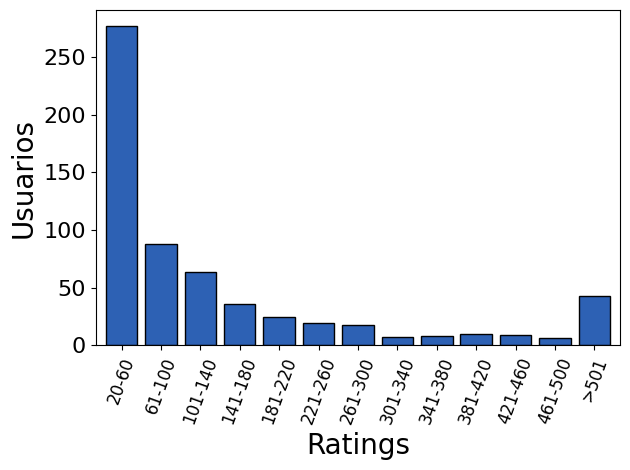

In [17]:
# plt.style.use("ggplot")
bins = [20,  60, 100, 140,180, 220, 260,300,340,380,420,460,500, float("inf")]
labels = ["20-60", "61-100", "101-140", "141-180", "181-220", "221-260", "261-300", "301-340", "341-380","381-420", "421-460", "461-500", ">501"]

grupos = pd.cut(valoracionesUser['numRatings'], bins=bins, labels=labels, include_lowest=True)
conteo = grupos.value_counts().reindex(labels)

fig, ax = plt.subplots()
conteo.plot.bar(ax=ax, edgecolor="black", color="#2D61B4", zorder=2, width=0.8)

plt.xlabel("Ratings", fontsize=20)
plt.ylabel("Usuarios", fontsize=20)
ax.set_xticklabels(labels, rotation=45, ha="right")
plt.xticks(fontsize=12,rotation=70,ha='center')
plt.yticks(fontsize=16)
plt.tight_layout()
# plt.grid(True, axis="y", color="black", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
plt.show()

### Numero de valoraciones por película

In [18]:
numValPel = ratings.groupby('movieId')['movieId'].count()
numValPel.describe()

count    9719.000000
mean       10.374113
std        22.405935
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: movieId, dtype: float64

In [19]:
numValPel.sort_values(ascending=True)

movieId
791         1
193565      1
191005      1
190221      1
190219      1
         ... 
2571      278
593       279
296       307
318       317
356       329
Name: movieId, Length: 9719, dtype: int64

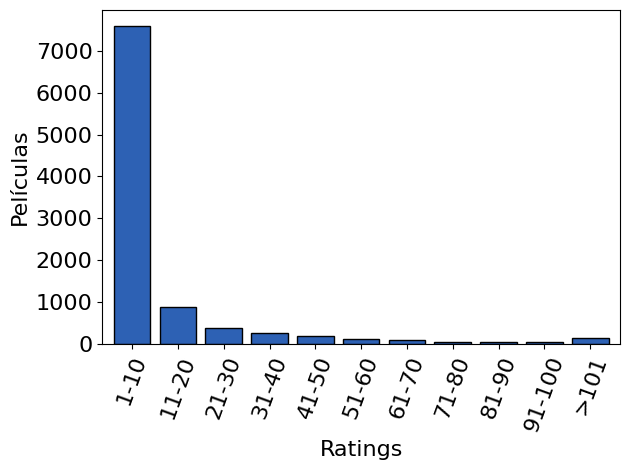

In [20]:

bins = [0, 10,  20, 30,40,50,60,70,80,90,100, float("inf")]
labels = ["1-10", "11-20", "21-30", "31-40", "41-50", "51-60", "61-70", "71-80", "81-90","91-100",">101"]

grupos = pd.cut(numValPel, bins=bins, labels=labels, include_lowest=True)
conteo = grupos.value_counts().reindex(labels)

fig, ax = plt.subplots()
conteo.plot.bar(ax=ax, edgecolor="black", color="#2D61B4", zorder=2, width=0.8)   
plt.style.use("ggplot")

plt.xlabel("Ratings",fontsize=16)
plt.ylabel("Películas",fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
ax.set_xticklabels(labels, rotation=70, ha="center")
# plt.grid(True, axis="y", color="black", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

## Dataset TMDB

In [21]:
TMDB = pd.read_parquet("../data/02_processed/TMDB_clean.parquet")
TMDB

,id,title,genres,popularity,poster_path,overview,tagline,vote_average,vote_count,runtime
0,2,Ariel,"[Comedy, Drama, Romance, Crime]",1.3807,/ojDg0PGvs6R9xYFodRct2kdI6wC.jpg,A Finnish man goes to the city to find a job a...,,7.121,375,73
1,5,Four Rooms,[Comedy],3.6807,/75aHn1NOYXh4M7L5shoeQ6NGykP.jpg,It's Ted the Bellhop's first night on the job....,Twelve outrageous guests. Four scandalous requ...,5.904,2847,98
2,6,Judgment Night,"[Action, Crime, Thriller]",1.8049,/3rvvpS9YPM5HB2f4HYiNiJVtdam.jpg,"Four young friends, while taking a shortcut en...",Don't move. Don't whisper. Don't even breathe.,6.463,377,109
3,11,Star Wars,"[Adventure, Action, Science Fiction]",27.0355,/6FfCtAuVAW8XJjZ7eWeLibRLWTw.jpg,Princess Leia is captured and held hostage by ...,"A long time ago in a galaxy far, far away...",8.205,22361,121
4,12,Finding Nemo,"[Animation, Family, Adventure]",19.5501,/5lc6nQc0VhWFYFbNv016xze8Jvy.jpg,"Nemo, an adventurous young clownfish, is unexp...",There are 3.7 trillion fish in the ocean. They...,7.819,20567,100
...,...,...,...,...,...,...,...,...,...,...
9615,497520,Tom Segura: Disgraceful,[Comedy],0.2180,/ll5QVhDsp6MbNWWZAGXc8vFu6Y9.jpg,Tom Segura gives voice to the sordid thoughts ...,,7.100,81,74
9616,500475,SuperFly,"[Action, Crime]",2.7139,/gGk9H5PVpWzbsYkmnBeKevQkwwf.jpg,Career criminal Youngblood Priest wants out of...,Redefine the hussle,6.706,406,107
9617,502616,Fred Armisen: Standup for Drummers,"[Music, Comedy]",0.2086,/2thxqf0Rbm2GaphAfAUdP8dvpXg.jpg,"For an audience of drummers, comedian Fred Arm...","I don't want to work, I just want to bang on t...",6.300,33,65
9618,503475,Wallace & Gromit: The Best of Aardman Animation,"[Family, Animation, Comedy]",0.6346,/tWkYclnnChwoMMBFECsEjd5hb77.jpg,Anthology of Aardman Animation short films rel...,The Best of Aardman Animation,7.600,5,75


In [22]:
# TMDB = pd.read_parquet("../data/03_gold/movieInfo.parquet")
# TMDB

Para hacer un gráfico circular con los géneros. 
Primero se separan los géneros y luego se agrupan

In [23]:
generos = TMDB.explode('genres').groupby('genres')['genres'].count()
generos

genres
Action             1900
Adventure          1373
Animation           598
Comedy             3935
Crime              1495
Documentary         415
Drama              4528
Family              909
Fantasy             901
History             458
Horror             1024
Music               363
Mystery             710
Romance            1974
Science Fiction    1060
TV Movie            163
Thriller           1988
War                 341
Western             176
Name: genres, dtype: int64

### Gráfico de sectores géneros (TMDB)

In [24]:
generos

genres
Action             1900
Adventure          1373
Animation           598
Comedy             3935
Crime              1495
Documentary         415
Drama              4528
Family              909
Fantasy             901
History             458
Horror             1024
Music               363
Mystery             710
Romance            1974
Science Fiction    1060
TV Movie            163
Thriller           1988
War                 341
Western             176
Name: genres, dtype: int64

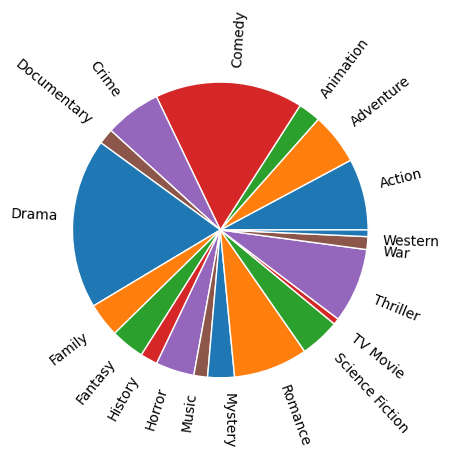

In [25]:
#grafico sectores TMDB
generos = TMDB.explode('genres').sort_values('genres').groupby('genres')['genres'].count()

grupos = generos.index
valor = generos.values
plt.style.use("ggplot")
fig, ax = plt.subplots()
colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
ax.pie(valor, labels = grupos, rotatelabels = True, wedgeprops = {"linewidth": 1, "edgecolor": "white"},colors = colores)
plt.show()

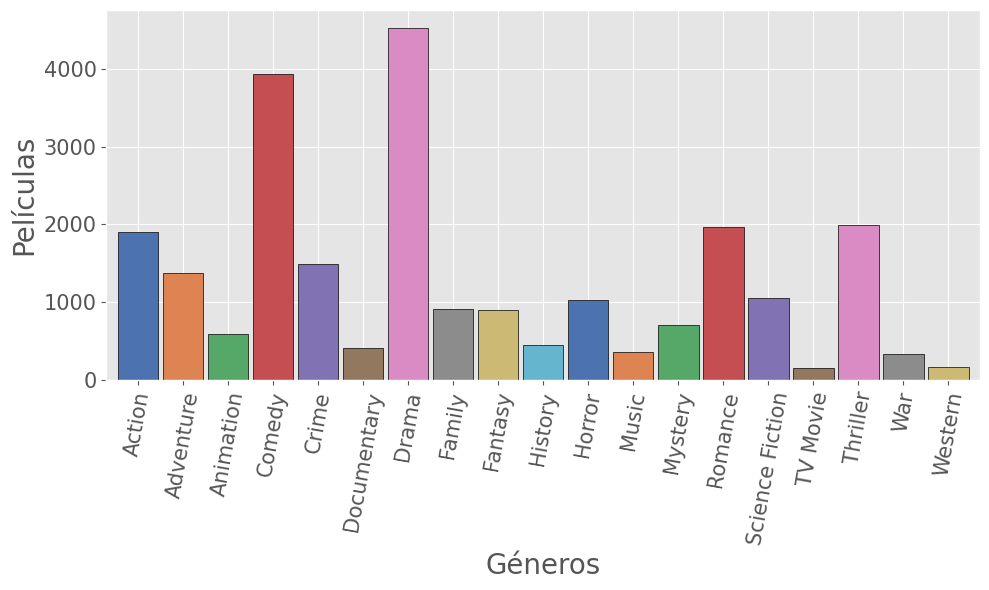

In [26]:
# plt.style.use("ggplot")
fig, ax = plt.subplots(figsize=(10,6))
colores = sns.color_palette("deep", len(generos))
generos.plot.bar(ax=ax, edgecolor="black", color=colores, zorder=2, width=0.9)   

plt.xlabel("Géneros", fontsize=20)
plt.ylabel("Películas", fontsize=20)
ax.set_xticklabels(generos.index, rotation=80,ha='center')
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.tight_layout()
plt.show()

In [27]:
# mismos graficos pero desde movies
movies = pd.read_parquet("../data/02_processed/movies_integrity.parquet")
movies['genres'] = movies['genres'].str.split('|') 
generos2 = movies.explode('genres').sort_values('genres').groupby('genres')['genres'].size()
generos2

genres
Action         1826
Adventure      1263
Animation       611
Children        664
Comedy         3755
Crime          1198
Documentary     439
Drama          4360
Fantasy         779
Film-Noir        87
Horror          978
IMAX            158
Musical         334
Mystery         573
Romance        1596
Sci-Fi          979
Thriller       1892
War             381
Western         167
Name: genres, dtype: int64

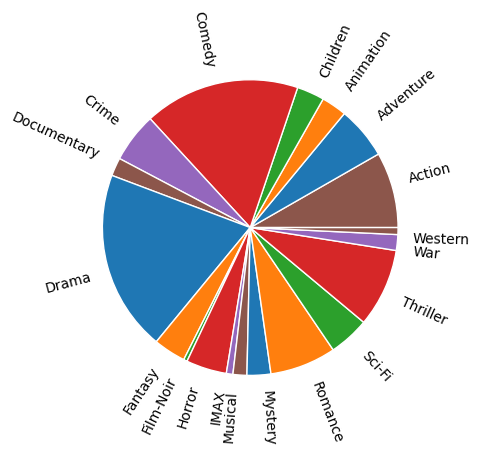

In [28]:
#grafico sectores géneros MOVIES
grupos2 = generos2.index
valor2 = generos2.values

fig, ax = plt.subplots()
colores = [ "#8c564b" ,"#1f77b4","#ff7f0e","#2ca02c","#d62728", "#9467bd"]
ax.pie(valor2, labels = grupos2, rotatelabels = True,  wedgeprops = {"linewidth": 1, "edgecolor": "white"}, colors=colores)
plt.show() 


In [29]:
plt.style.use("default")

In [30]:
generos2

genres
Action         1826
Adventure      1263
Animation       611
Children        664
Comedy         3755
Crime          1198
Documentary     439
Drama          4360
Fantasy         779
Film-Noir        87
Horror          978
IMAX            158
Musical         334
Mystery         573
Romance        1596
Sci-Fi          979
Thriller       1892
War             381
Western         167
Name: genres, dtype: int64

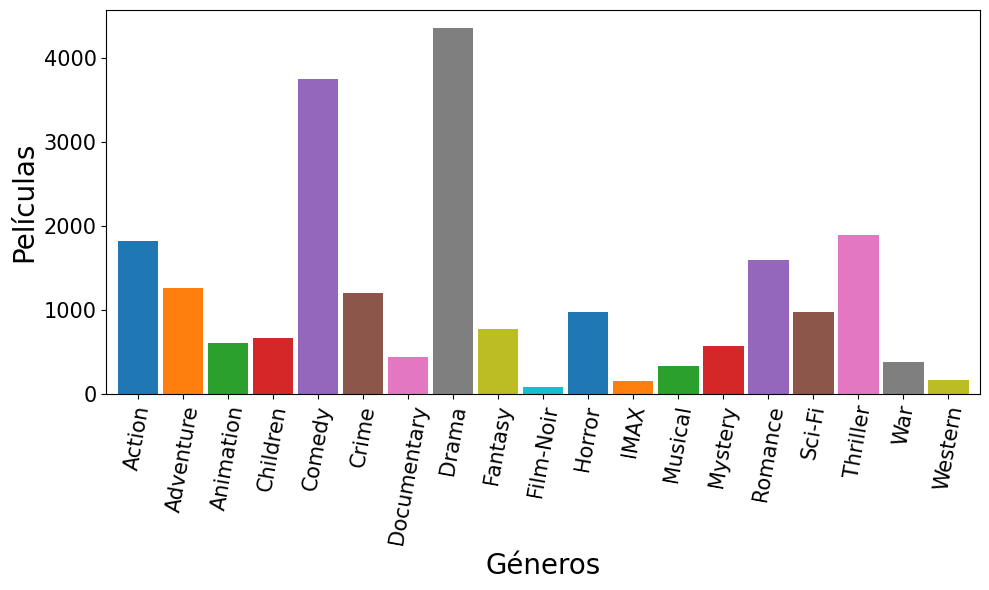

In [31]:

# plt.style.use("ggplot")
fig, ax = plt.subplots(figsize=(10,6))
colores = sns.color_palette("tab10", len(generos2))
generos2.plot.bar(ax=ax, edgecolor=None, color=colores, zorder=2, width=0.9)   

plt.xlabel("Géneros", fontsize=20)
plt.ylabel("Películas", fontsize=20)
ax.set_xticklabels(generos2.index, rotation=80,ha='center')
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.tight_layout()
plt.show()

In [32]:
media

np.float64(3.501581933231508)

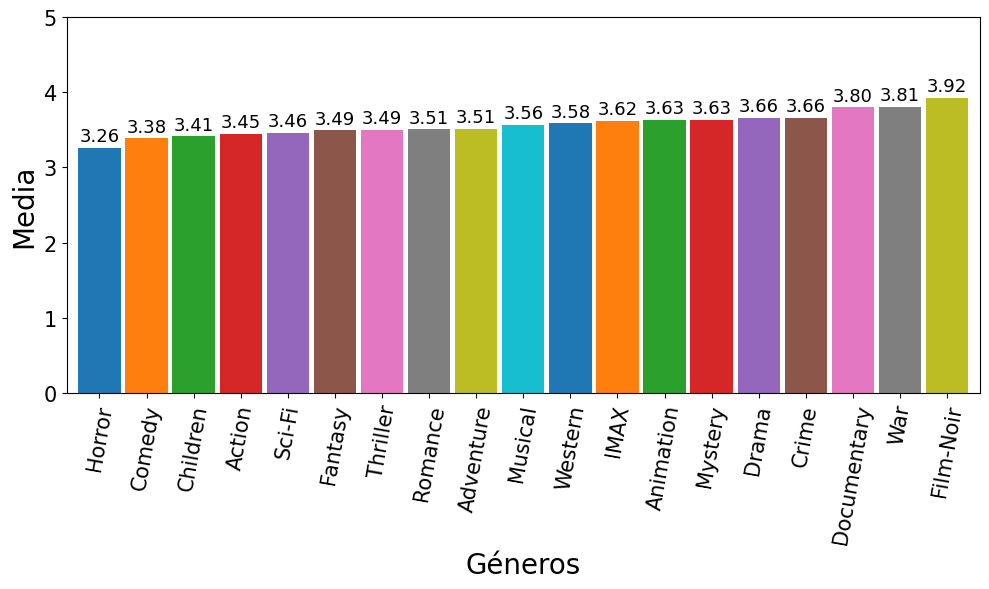

In [33]:
# media de ratings por generos
datos = pd.merge(movies.explode('genres'), ratings, on="movieId")
media = datos.groupby('genres')['rating'].mean().sort_values()
fig, ax = plt.subplots(figsize=(10,6))
colores = sns.color_palette("tab10", len(generos2))
media.plot.bar(ax=ax, edgecolor=None, color=colores, zorder=2, width=0.9)   
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=13)
plt.xlabel("Géneros", fontsize=20)
plt.ylabel("Media", fontsize=20)
ax.set_ylim(0, 5)
ax.set_xticklabels(media.index, rotation=80,ha='center')
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.tight_layout()
plt.show()

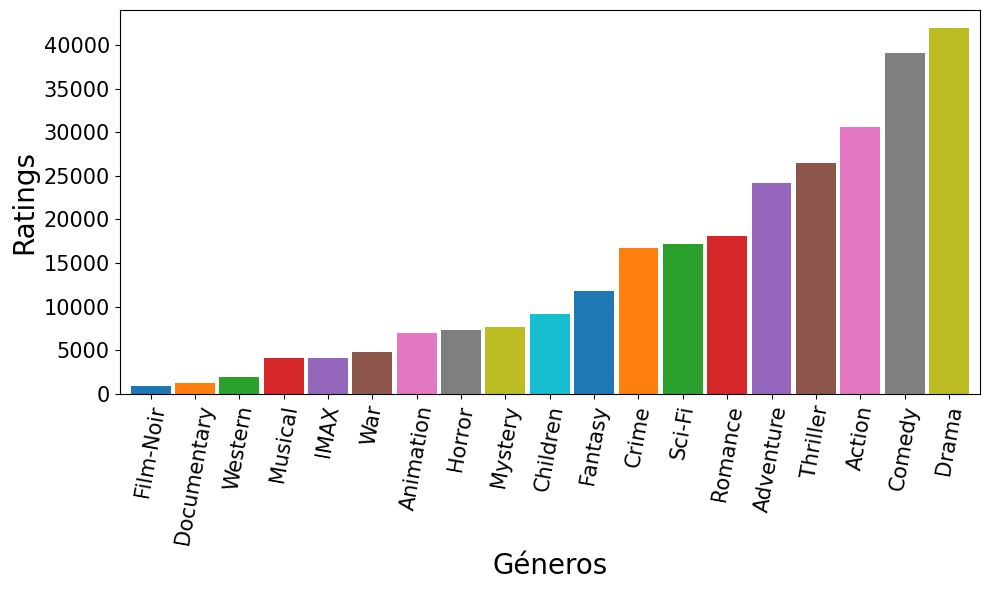

In [34]:
#numero de ratings por cada genero
datos = pd.merge(movies.explode('genres'), ratings, on="movieId")
cuenta = datos.groupby('genres')['rating'].count().sort_values()
cuenta
fig, ax = plt.subplots(figsize=(10,6))
colores = sns.color_palette("tab10", len(generos2))
cuenta.plot.bar(ax=ax, edgecolor=None, color=colores, zorder=2, width=0.9)   
plt.xlabel("Géneros", fontsize=20)
plt.ylabel("Ratings", fontsize=20)
ax.set_xticklabels(cuenta.index, rotation=80,ha='center')
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.tight_layout()
plt.show()

In [35]:
generos.index

Index(['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary',
       'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery',
       'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western'],
      dtype='str', name='genres')

### Evolución temporal de las valoraciones

In [36]:
ratings['timestamp'] = ratings['timestamp'].dt.year


In [37]:
peliculasAnios = ratings.groupby('timestamp').size()

In [38]:
peliculasAnios

timestamp
1996     6040
1997     1916
1998      507
1999     2437
2000    10060
2001     3921
2002     3477
2003     4013
2004     3279
2005     5813
2006     4058
2007     7113
2008     4351
2009     4158
2010     2301
2011     1690
2012     4655
2013     1664
2014     1439
2015     6616
2016     6702
2017     8198
2018     6418
dtype: int64

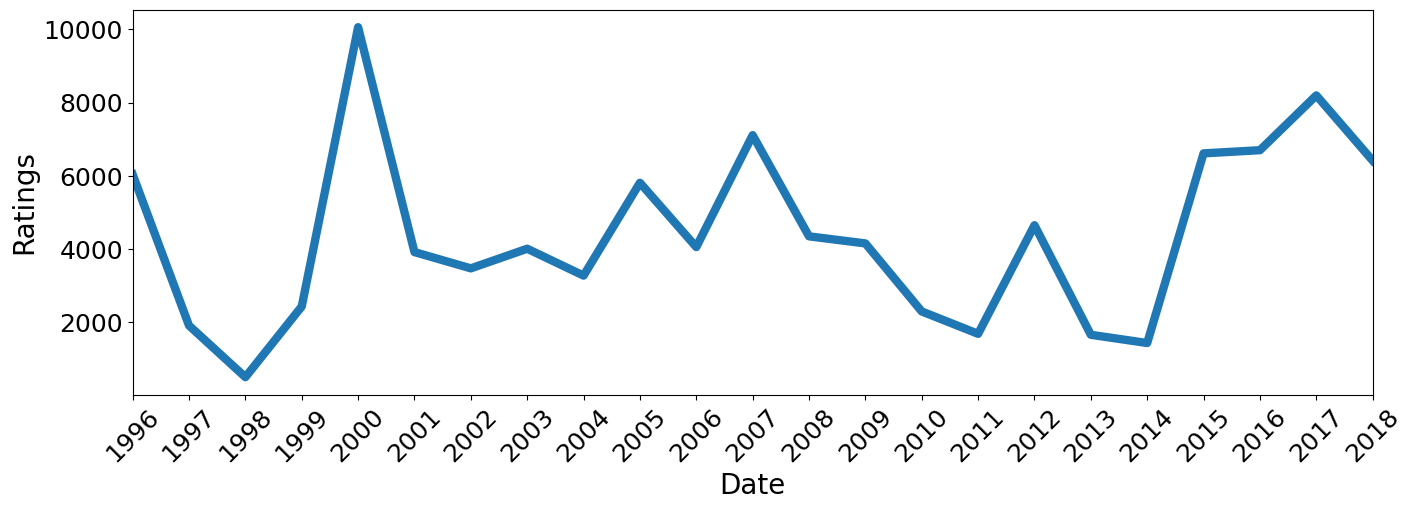

In [39]:
fig = plt.subplots(figsize=(16, 5))
plt.plot(peliculasAnios.index, peliculasAnios.values,linewidth=6)

plt.xlabel('Date', fontsize=20)
plt.ylabel('Ratings', fontsize=20)
plt.xlim(peliculasAnios.index.min(), peliculasAnios.index.max())

ticks = list(peliculasAnios.index)
plt.yticks(fontsize=18)
plt.xticks(ticks, rotation=45, fontsize=18)
plt.show()

## análisis de las dificultades

In [40]:
# Número de ratings
nRatings = len(ratings)
nRatings

100826

In [41]:
# matriz de dispersión
nUsuarios = ratings['userId'].nunique()
nPeliculas = movies['movieId'].nunique()

#celdas posibles vs reales
celdas_posibles = nUsuarios * nPeliculas
celdas_reales = len(ratings)

# Densidad y dispersion
densidad = celdas_reales / celdas_posibles
dispersion = 1 - densidad

#resultados
print(f"Usuarios: {nUsuarios}")
print(f"Películas: {nPeliculas}")
print(f"Celdas posibles: {celdas_posibles}")
print(f"Ratings reales: {celdas_reales}")
print(f"Densidad: {densidad:.4}")
print(f"Dispersidad: {dispersion:.4}")

Usuarios: 610
Películas: 9737
Celdas posibles: 5939570
Ratings reales: 100826
Densidad: 0.01698
Dispersidad: 0.983
